# Upgrade CANN and MindSpore

The official 2025-09-09 Ubuntu 22.04 desktop image for OrangePi AIpro \(20T\) has the following software versions installed.

1. CANN version: `8.0.0`
1. MindSpore version: `2.4.10`

We'd like to use the latest stable CANN and MindSpore versions as of March 2026 for our Ascend AI/ML experiments.

1. CANN version: `8.5.0`
1. MindSpore version: `2.8.0`

The high-level upgrade procedure is outlined below.

1. Uninstall CANN `8.0.0` toolkit and kernels
1. Install CANN `8.5.0` toolkit, kernels and neural network accelerator library \(NNAL\)
1. Replace Conda with `pyenv` and create virtual environment \(optional\)
1. Install/Upgrade MindSpore 2.8.0 and related dependencies
1. Install JupyterLab extensions \(optional\)

## Uninstall CANN `8.0.0` toolkit and kernels

These steps should be performed directly as `root` on the command line and shown below solely for reference. Do not execute them in this notebook directly.

```bash
# Run the CANN uninstall.sh script as root
/usr/local/Ascend/ascend-toolkit/latest/aarch64-linux/script/uninstall.sh

# Remove remaining files and directories under /usr/local/Ascend/ascend-toolkit
rm -rvf /usr/local/Ascend/ascend-toolkit/*
```

## Install CANN `8.5.0` toolkit, kernels and NNAL

These steps should be performed directly as `root` on the command line and shown below solely for reference. Do not execute them in this notebook directly.

Navigate to the Ascend [CANN download page](https://www.hiascend.com/developer/download/community/result?module=cann&cann=8.5.0) and select the following options.

1. Version: `8.5.0`
1. Architecture: `aarch64`
1. Package format: `.run`

Download the following packages and transfer them to your development board.

1. `Ascend-cann-toolkit_8.5.0_linux-aarch64.run`: CANN toolkit framework
1. `Ascend-cann-310b-ops_8.5.0_linux-aarch64.run`: CANN kernels operators library
1. `Ascend-cann-nnal_8.5.0_linux-aarch64.run`: CANN neural network accelerator library \(NNAL\)

In [1]:
from IPython.display import Image

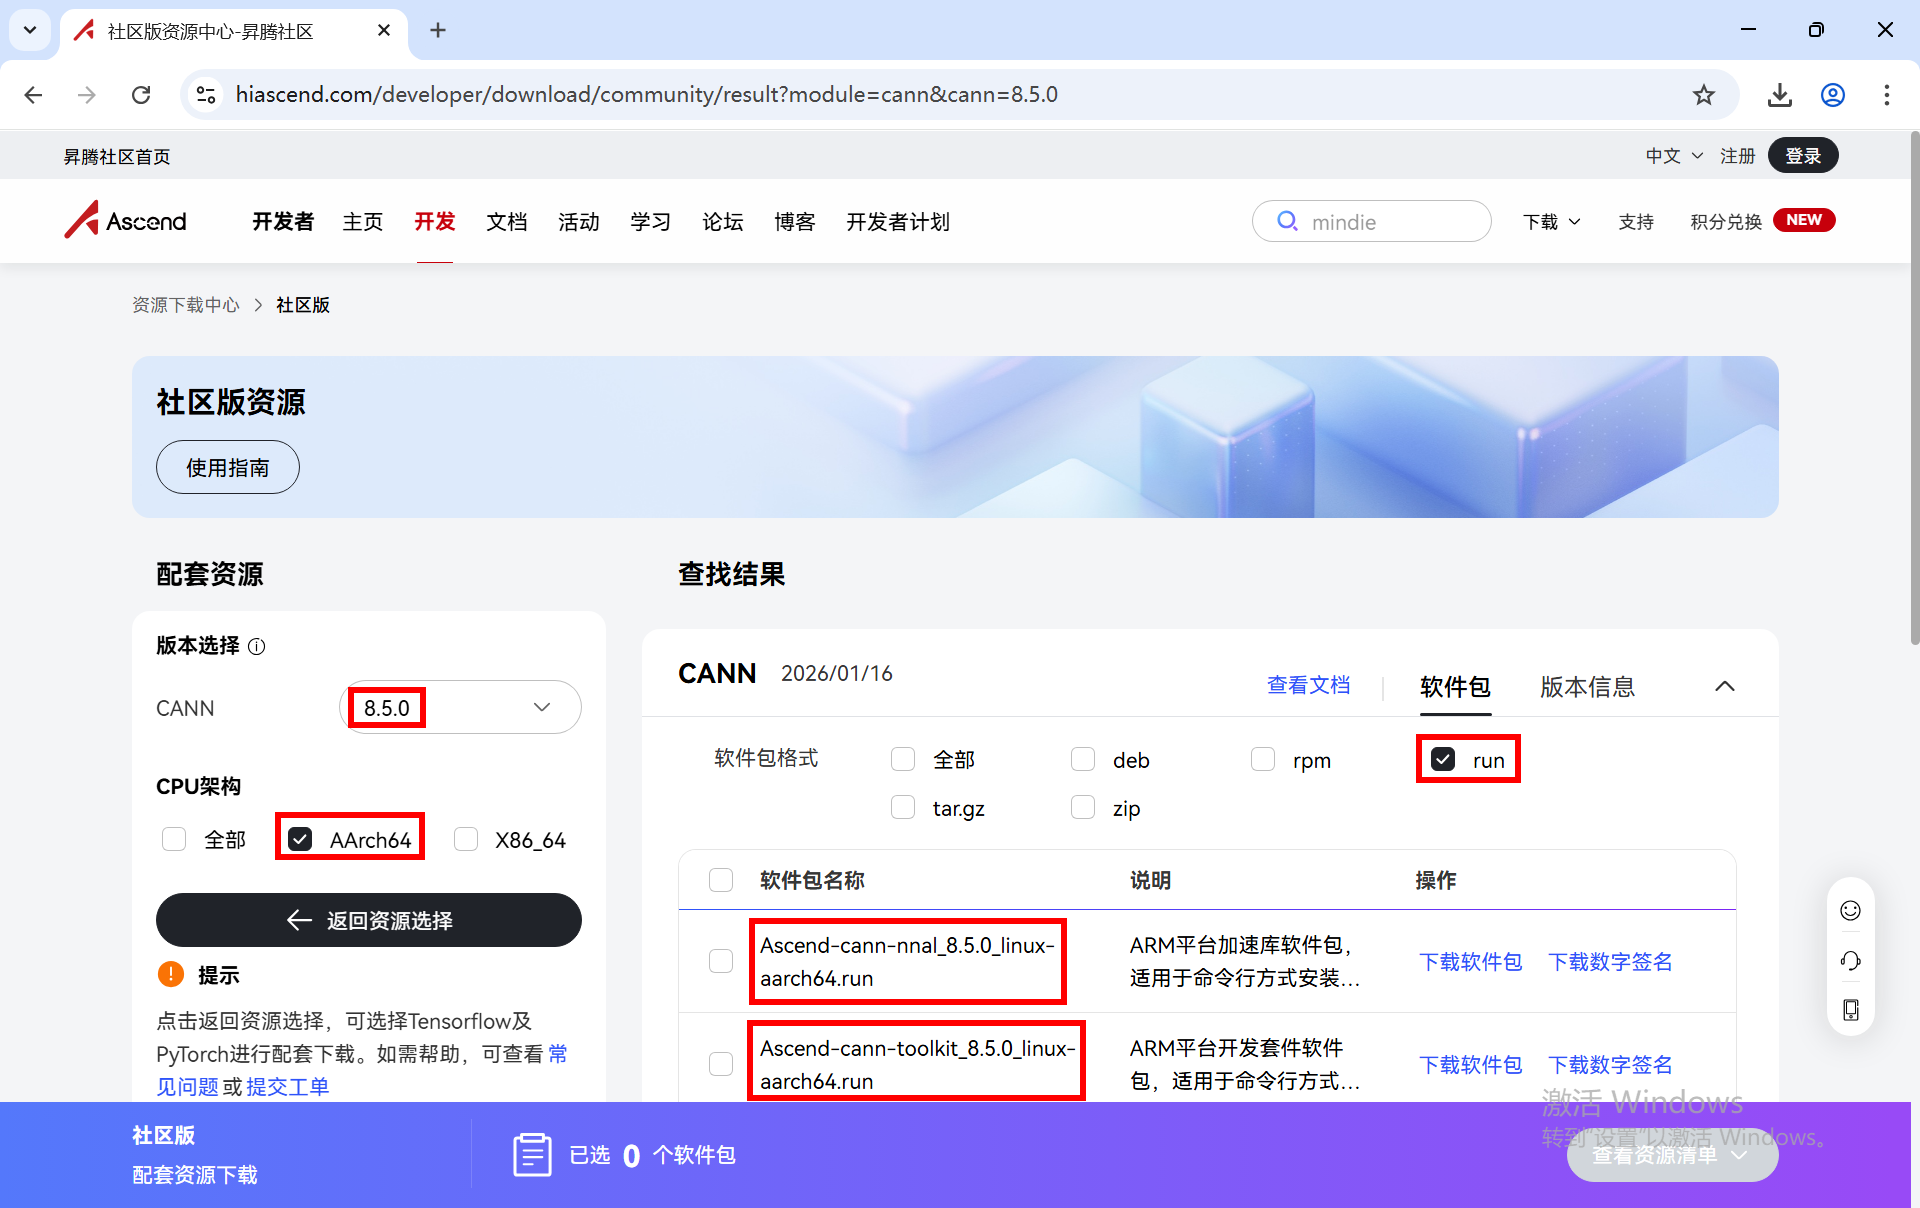

In [2]:
Image(filename='00-cann-version-arch-toolkit-nnal.png')

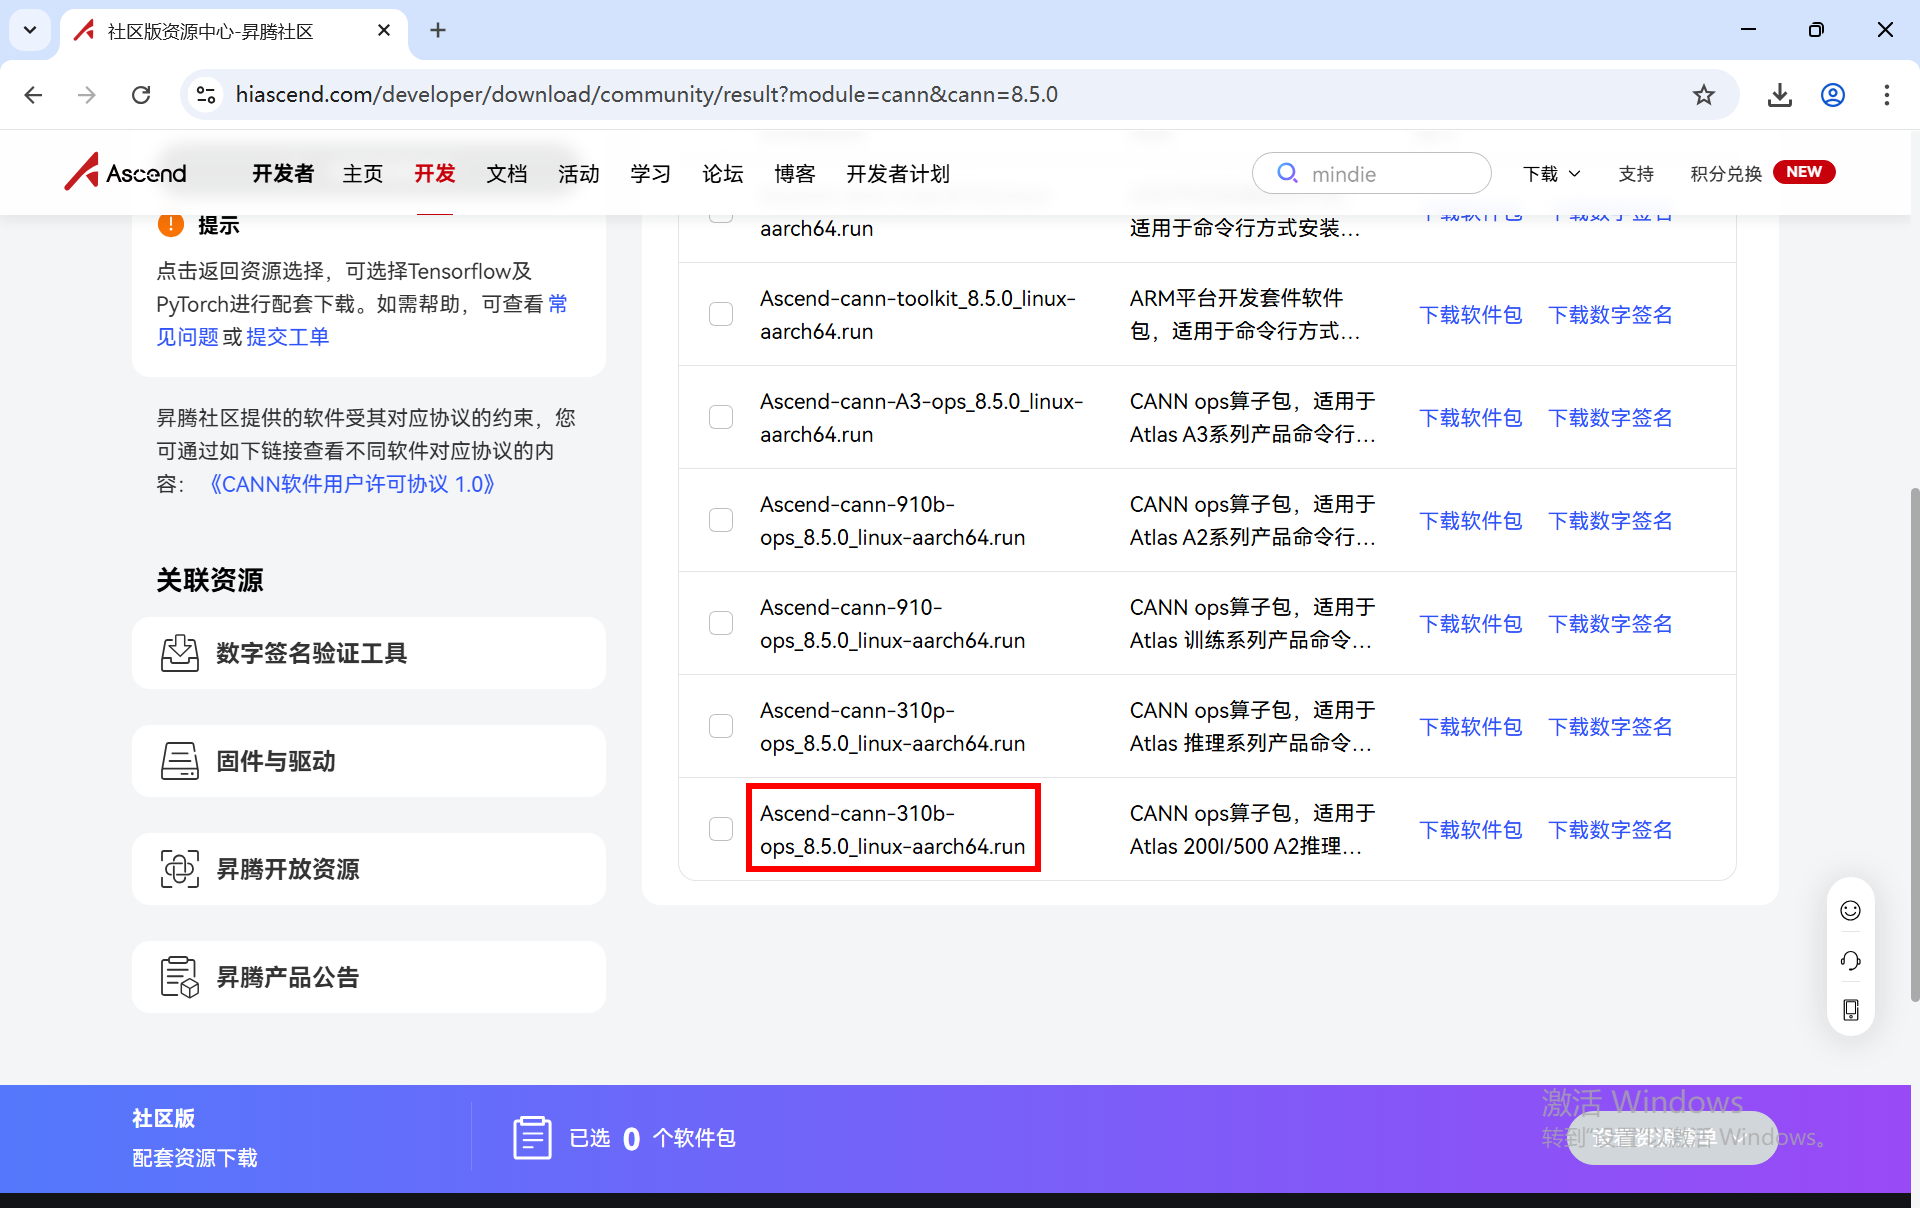

In [3]:
Image(filename='01-cann-ascend310b-ops-kernels.png')

Run the following commands as `root`. Accept the EULA when prompted, wait for each component to be installed and report success.

```bash
# Make the installers executable
chmod +x ./*.run

# Install the CANN toolkit
./Ascend-cann-toolkit_8.5.0_linux-aarch64.run --install

# Install the Ascend 310B kernels package
./Ascend-cann-310b-ops_8.5.0_linux-aarch64.run --install

# Install the neural network accelerator library
./Ascend-cann-nnal_8.5.0_linux-aarch64.run --install
```

Make sure the following line is in your `~/.bashrc`.

```bash
source /usr/local/Ascend/ascend-toolkit/set_env.sh
```

Source your `~/.bashrc` to update Ascend-related environment variables.

```bash
source ~/.bashrc
```

## Replace Conda with `pyenv` and create virtual environment \(optional\)

[Conda](https://github.com/conda/conda) is pre-installed and pre-configured with the official 2025-09-09 Ubuntu 22.04 LTS desktop image for OrangePi AIpro \(20T\). It's known for its popularity in the AI/ML and data science field but has its own drawbacks.

1. The OrangePi AIpro \(20T\) user guide assumes Python packages are installed directly to Conda's `base` environment. When working with multiple projects simultaneously, this can frequently introduce package conflicts which are difficult to troubleshoot and resolve
1. Conda supports creating virtual environments to isolate project dependencies which solves the issue in \(1\). However, it uses an environment solver which is known to be slow and inefficient - see for example this GitHub issue: [conda/conda#11919](https://github.com/conda/conda/issues/11919)

To solve these issues, I found [pyenv/pyenv](https://github.com/pyenv/pyenv) useful. `pyenv` is a simple, straightforward Python version manager and wrapper around Python-native virtual environments [`venv`](https://docs.python.org/3/library/venv.html) which doesn't have the quirks and overhead of Conda.

This section is optional but follow me if you wish to replace Conda with pyenv.

### Uninstall Conda

```bash
# Remove Conda-specific initialization from your ~/.bashrc
# Repeat for both HwHiAiUser and root users
# Restart your shell afterwards
conda init --reverse --all

# Uninstall Miniconda as root
sudo rm -rvf /usr/local/miniconda3

# Remove Conda-specific files and directories
# Repeat for both HwHiAiUser and root users
rm -rvf ~/.condarc ~/.conda ~/.continuum
```

### Install `pyenv`

```bash
# Install pyenv
# Follow the on-screen instructions once installed to initialize pyenv and add it to your PATH
curl -fsSL https://pyenv.run | bash

# Install Python build dependencies
sudo apt update && sudo apt install make build-essential libssl-dev zlib1g-dev \
    libbz2-dev libreadline-dev libsqlite3-dev curl git \
    libncursesw5-dev xz-utils tk-dev libxml2-dev libxmlsec1-dev libffi-dev liblzma-dev \
    libzstd-dev

# Example: install a specific Python version with pyenv
# MindSpore 2.8.0 supports Python 3.9-3.12
pyenv install 3.12

# Example: create a virtual environment `my-venv` with Python 3.12
pyenv virtualenv 3.12 my-venv

# Example: activate the virtual environment `my-venv`
pyenv activate my-venv
```

## Install/Upgrade MindSpore 2.8.0 and related dependencies

In your virtual environment or Conda base environment, install MindSpore 2.8.0. Additional dependencies must be installed required by CANN 8.5.0.

```text
absl-py==2.4.0
attrs==25.4.0
cloudpickle==3.1.2
decorator==5.2.1
mindspore==2.8.0
ml-dtypes==0.5.4
sympy==1.14.0
tornado==6.5.5
```

These packages are also listed in the `requirements.txt` included within this directory.

In [4]:
%pip install absl-py==2.4.0 \
    attrs==25.4.0 \
    cloudpickle==3.1.2 \
    decorator==5.2.1 \
    mindspore==2.8.0 \
    ml-dtypes==0.5.4 \
    sympy==1.14.0 \
    tornado==6.5.5


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Verify MindSpore 2.8.0 is successfully installed. MindSpore 2.8.0 recommends the `mindspore.set_device` function over the deprecated `mindspore.set_context` function.

In [5]:
import mindspore
mindspore.set_device(device_target='Ascend')
mindspore.run_check()

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

MindSpore version:  2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!


Warnings are normal unless you see any `[ERROR]` or `[CRITICAL]` message, in which case seek for advice in the Ascend forum. As long as you see the message below, MindSpore 2.8.0 is installed successfully.

```text
MindSpore version:  2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!
```

## Install JupyterLab extensions \(optional\)

The base environment of the official Ubuntu 22.04 LTS desktop image only has the core JupyterLab installed. In practice, I find the following Jupyter extensions useful for most projects.

1. [jupyterlab/jupyterlab-git](https://github.com/jupyterlab/jupyterlab-git): an extension for managing Git repositories in JupyterLab
1. [jupyter-server/jupyter-resource-usage](https://github.com/jupyter-server/jupyter-resource-usage): monitor the CPU and memory resource usage of your JupyterLab and notebook kernel. It doesn't seem to support monitoring Ascend NPU usage yet as of March 2026

You can install them with `pip`. For example:

```bash
pip install jupyterlab-git jupyter-resource-usage
```